# 1. AMZN data and feature representation

**Question:** what structure must a realistic generated order book preserve?
We use the LOBSTER AMZN level-10 sample for 21 June 2012: ten ask and bid prices,
with their order sizes, at each recorded event. Prices are stored in 1/10,000 dollars;
one cent is 100 stored units. Sizes are shares.

This chapter combines the original book exploration, basic statistics, and preprocessing
checks. The first 85% of events form the training split; the final 15% form validation.
The full-day plot is descriptive. Feature normalization uses training events only.
The model works in **event order**, not elapsed clock time.

Next: [baseline TimeGAN](lobster_timegan.ipynb).


In [1]:
from pathlib import Path
import sys

project_dir = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'dataset.py').is_file())
sys.path.insert(0, str(project_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Markdown
from dataset import LOBSTERLevel10Dataset, WindowDataset

torch.set_num_threads(1)

from dataset import load_dfs

books, messages = load_dfs()
training = LOBSTERLevel10Dataset(True)
validation = LOBSTERLevel10Dataset(False)
boundary = len(training)
midpoint = (books['ASKp1'] + books['BIDp1']) / 20_000
spread = (books['ASKp1'] - books['BIDp1']) / 10_000
times = pd.Timestamp('2012-06-21', tz='America/New_York') + pd.to_timedelta(messages['time'], unit='s')
display(pd.DataFrame({'Events': [len(training), len(validation)],
                      'First time': [times.iloc[0], times.iloc[boundary]],
                      'Last time': [times.iloc[boundary - 1], times.iloc[-1]]},
                     index=['Training', 'Validation']))


,Events,First time,Last time
Training,229286,2012-06-21 09:30:00.017459617-04:00,2012-06-21 15:22:21.359788239-04:00
Validation,40462,2012-06-21 15:22:21.359796425-04:00,2012-06-21 15:59:59.959359650-04:00


## The trading day and the spread

The price bands cover bid-to-ask ranges at levels 1, 5, and 10. Their shading represents
quote ranges, not confidence or volume. Clock time shows the session; the vertical line
marks the chronological split. The distribution panel uses training events only.


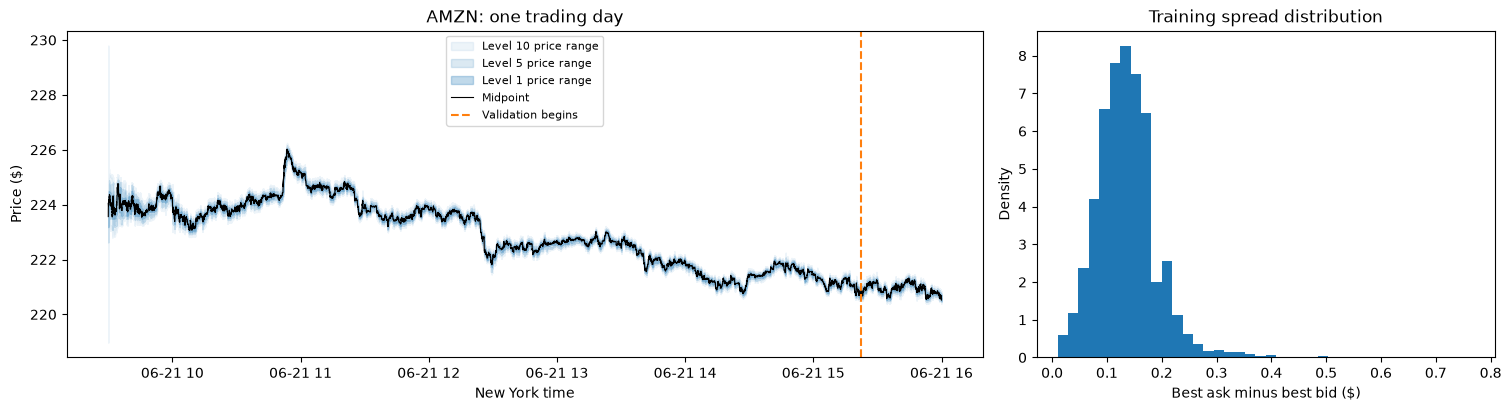

Mean       SD  Minimum  Maximum
Quantity     Split                                           
Midpoint ($) Training    223.03437  1.27528   220.69  226.025
             Validation  220.92026  0.17902   220.52  221.325
Spread ($)   Training      0.13668  0.05702     0.01    0.770
             Validation    0.09791  0.04238     0.01    0.240

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), width_ratios=[2, 1], layout='constrained')
for level, alpha in [(10, 0.08), (5, 0.16), (1, 0.28)]:
    axes[0].fill_between(times, books[f'BIDp{level}'] / 10_000,
                         books[f'ASKp{level}'] / 10_000, alpha=alpha,
                         color='tab:blue', label=f'Level {level} price range')
axes[0].plot(times, midpoint, linewidth=0.8, color='black', label='Midpoint')
axes[0].axvline(times.iloc[boundary], color='tab:orange', linestyle='--', label='Validation begins')
axes[0].set(title='AMZN: one trading day', xlabel='New York time', ylabel='Price ($)')
axes[0].legend(fontsize=8)
axes[1].hist(spread.iloc[:boundary], bins=40, density=True, color='tab:blue')
axes[1].set(title='Training spread distribution', xlabel='Best ask minus best bid ($)', ylabel='Density')
plt.show()

rows = []
for name, values in [('Midpoint ($)', midpoint), ('Spread ($)', spread)]:
    for split, values_split in [('Training', values.iloc[:boundary]), ('Validation', values.iloc[boundary:])]:
        rows.append({'Quantity': name, 'Split': split, 'Mean': values_split.mean(),
                     'SD': values_split.std(ddof=0), 'Minimum': values_split.min(), 'Maximum': values_split.max()})
display(pd.DataFrame(rows).set_index(['Quantity', 'Split']).round(5))


## Adjacent price gaps and market-open observations

Ask prices increase through the levels; bid prices decrease. Positive adjacent gaps,
spread, and sizes motivate a constrained book representation. These are **gap levels**;
chapter 4 separately measures their changes between events.

A few large opening gaps can dominate Pearson correlations. We retain those observations
in training and summarize their influence below. A smaller correlation after excluding
large gaps is a sensitivity check, not proof that gaps are independent.


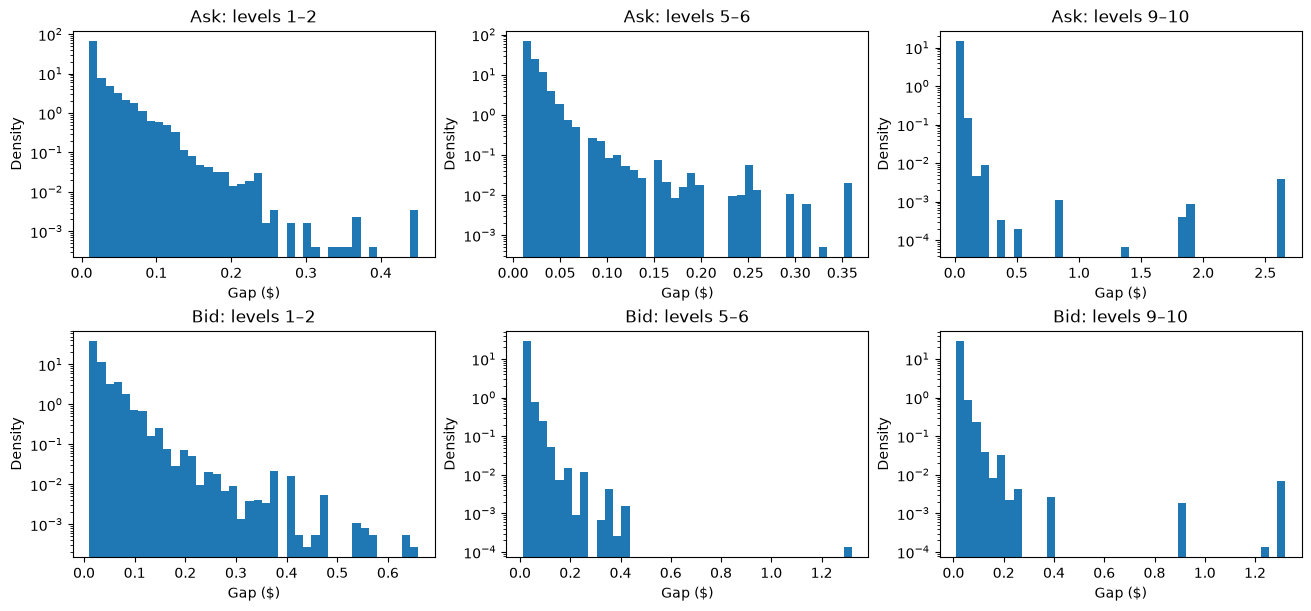

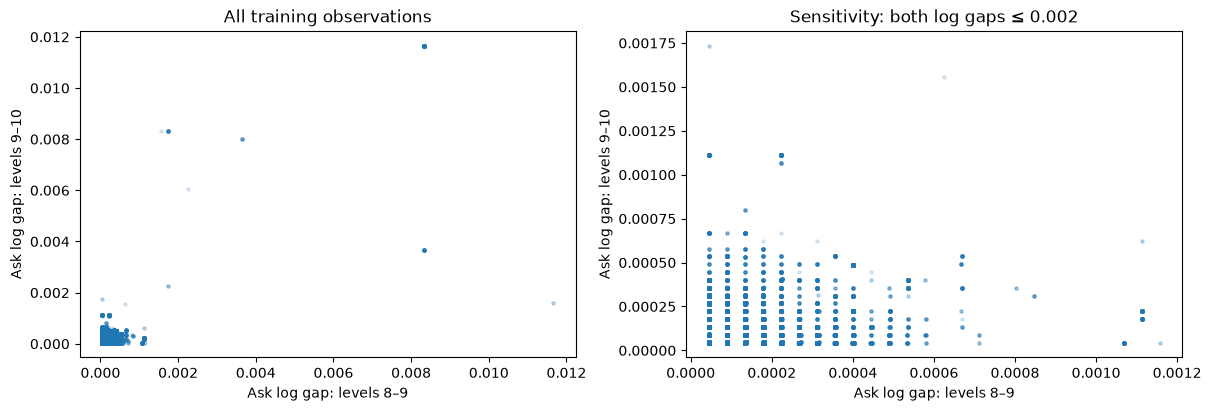

Correlation, all                                     0.811680
Correlation, smaller gaps                            0.176394
Large-gap observations                             101.000000
Share of large-gap observations in first second      1.000000
Name: Opening-gap sensitivity, dtype: float64

In [3]:
asks = books[[f'ASKp{i}' for i in range(1, 11)]].to_numpy()
bids = books[[f'BIDp{i}' for i in range(1, 11)]].to_numpy()
ask_gaps = np.diff(asks, axis=1) / 10_000
bid_gaps = -np.diff(bids, axis=1) / 10_000
fig, axes = plt.subplots(2, 3, figsize=(13, 6), layout='constrained')
for row, (side, gaps) in enumerate([('Ask', ask_gaps), ('Bid', bid_gaps)]):
    for ax, gap_index in zip(axes[row], [0, 4, 8]):
        ax.hist(gaps[:boundary, gap_index], bins=40, density=True)
        ax.set(title=f'{side}: levels {gap_index + 1}–{gap_index + 2}', xlabel='Gap ($)', ylabel='Density')
        ax.set_yscale('log')
plt.show()

# Revisit the originally observed opening outliers in log-price gaps.
log_ask_gaps = np.diff(np.log(asks), axis=1)
x, y = log_ask_gaps[:boundary, 7], log_ask_gaps[:boundary, 8]
large = (x > 0.002) | (y > 0.002)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
for ax, keep, title in [(axes[0], np.ones(len(x), dtype=bool), 'All training observations'),
                        (axes[1], ~large, 'Sensitivity: both log gaps ≤ 0.002')]:
    ax.scatter(x[keep], y[keep], s=5, alpha=0.15)
    ax.set(title=title, xlabel='Ask log gap: levels 8–9', ylabel='Ask log gap: levels 9–10')
plt.show()
display(pd.Series({'Correlation, all': np.corrcoef(x, y)[0, 1],
                   'Correlation, smaller gaps': np.corrcoef(x[~large], y[~large])[0, 1],
                   'Large-gap observations': int(large.sum()),
                   'Share of large-gap observations in first second':
                       (messages['time'].iloc[:boundary].to_numpy()[large] < 34201).mean()},
                  name='Opening-gap sensitivity'))


## Forty features, fitted on training events

| Feature block | Count | Transformation |
|---|---:|---|
| Midpoint | 1 | Log midpoint in stored price units |
| Spread | 1 | `log1p(spread / tick_size)` |
| Adjacent ask and bid gaps | 18 | `log1p(gap / tick_size)` |
| Ask and bid sizes | 20 | `log1p(shares)` |

Each feature is standardized by its training mean and SD. The later return variant
replaces **only the midpoint feature** with the event-to-event log midpoint return.
Its first validation return uses the last training midpoint, a past observation.
Its other 39 features and their normalization are unchanged.


In [4]:
return_training = LOBSTERLevel10Dataset(True, price_representation='return')
return_validation = LOBSTERLevel10Dataset(False, price_representation='return')
np.testing.assert_array_equal(training.feature_mean, validation.feature_mean)
np.testing.assert_array_equal(return_training.feature_mean, return_validation.feature_mean)
np.testing.assert_array_equal(training.feature_mean[1:], return_training.feature_mean[1:])
display(pd.DataFrame({'Feature': [training.feature_names[0], training.feature_names[1],
                                return_training.feature_names[0]],
                      'Training mean before standardization': [training.feature_mean[0],
                           training.feature_mean[1], return_training.feature_mean[0]],
                      'Training SD before standardization': [training.feature_std[0],
                           training.feature_std[1], return_training.feature_std[0]]}).set_index('Feature'))
print('Feature shape:', tuple(training.features.shape))


,Training mean before standardization,Training SD before standardization
Feature,,
log_midpoint,1.461765e+01,0.005720
log1p_spread,2.606340e+00,0.421128
log_midpoint_return,-5.141351e-08,0.000034


Feature shape: (229286, 40)


## Windows and conversion back to books

Windows are constructed within each split, so no window crosses the boundary.
Shuffling changes window order without rearranging events within a window.
Training uses overlapping windows; evaluation uses nonoverlapping windows.

The check below reverses normalization on the first 64 validation events.
Return decoding starts from the last training midpoint and resets its anchor for each
independent sequence. Book conversion rounds prices to ticks and enforces positive
spread, gaps, and sizes. Valid snapshots after this projection do not prove realistic dynamics.


In [5]:
length = 64
train_windows = WindowDataset(training.features, length)
validation_windows = WindowDataset(validation.features, length)
torch.testing.assert_close(train_windows[-1], training.features[-length:])
torch.testing.assert_close(validation_windows[0], validation.features[:length])
anchor = (training.books['ASKp1'].iloc[-1] + training.books['BIDp1'].iloc[-1]) / 2
original = validation.books.iloc[:length].to_numpy()
checks = []
for label, data in [('Price levels', validation), ('Returns', return_validation)]:
    decoded = data.feature_sequence_to_df(data.features[:length], initial_midpoint=anchor).to_numpy()
    price_columns = np.r_[np.arange(0, 40, 4), np.arange(2, 40, 4)]
    size_columns = np.r_[np.arange(1, 40, 4), np.arange(3, 40, 4)]
    checks.append({'Representation': label,
                   'Max price error ($)': np.abs(decoded[:, price_columns] - original[:, price_columns]).max() / 10_000,
                   'Max size error (shares)': np.abs(decoded[:, size_columns] - original[:, size_columns]).max()})
display(pd.DataFrame(checks).set_index('Representation'))
print(f'Overlapping training/validation windows: {len(train_windows):,} / {len(validation_windows):,}')


,Max price error ($),Max size error (shares)
Representation,,
Price levels,0.0,0
Returns,0.0,0


Overlapping training/validation windows: 229,223 / 40,399


## What this establishes

The representation preserves the ten-level snapshot structure and provides chronological,
training-normalized sequences. Opening observations can have substantial influence and remain
part of the modeled day. The next chapter checks reconstruction and generation separately:
recovering an observed book is a prerequisite, not evidence of successful synthetic generation.
